# ¿Cuál es la motivación para este análisis?
##### NOTA: Los datos trabajados en este portafolio son de carácter público, se encuentra de acceso libre en la página del MinTic de Colombia
##### Se plantearon las siguientes preguntas que permitirán conocer cuál es el contexto que vive Colombia en cuanto uso y cobertura de telefonía móvil y fija, respuesta que nos dará el modelado y visualización de los datos.

<ol>
<li>¿Qué operador tiene más abonados (usuarios) de internet móvil en Colombia?</li>
<li>¿Cómo evolucionó el tráfico de datos móviles por proveedor 2023-2025?</li>
<li>¿Qué municipios tienen menor cobertura de servicio móvil?</li>
<li>¿Relación entre líneas móviles e ingresos por proveedor?</li>
<li>¿Qué departamentos concentran mayor brecha digital en acceso fijo?</li>
</ol>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
df_accesos_fijos = pd.read_csv("../data/processed/accesos_fijos.csv")
df_abonados_moviles = pd.read_csv("../data/processed/abonados_moviles.csv")
df_trafico_movil = pd.read_csv("../data/processed/trafico_movil.csv")
df_lineas_moviles = pd.read_csv("../data/processed/lineas_moviles.csv")
df_ingresos_por_voz = pd.read_csv("../data/processed/ingresos_por_voz.csv")
df_cobertura_movil_por_municipio = pd.read_csv("../data/processed/cobertura_movil_por_municipio.csv")

#### Las columnas de tecnología en la tabla Cobertura movil por municipio deben pasar a tipo Booleano
##### Esto es para que ocupe menos espacio en memoria y sea mejor el procesamiento. 

In [3]:
#Conversión de tipo de dato STR a BOOLEAN
df_cobertura_movil_por_municipio.dtypes
columnas_cobertura = ["2G","3G","HSPA+","4G","LTE","5G"]

for col in columnas_cobertura:
    df_cobertura_movil_por_municipio[col] = df_cobertura_movil_por_municipio[col].map({"S": True, "N":False})

In [4]:
#Corroboramos cambios
df_cobertura_movil_por_municipio.dtypes
print(df_cobertura_movil_por_municipio.head())

    AÑO  TRIMESTRE                PROVEEDOR  CÓDIGO DANE DEPARTAMENTO  \
0  2023          2  COLOMBIA MOVIL  S.A ESP           91     AMAZONAS   
1  2023          2  COLOMBIA MOVIL  S.A ESP           91     AMAZONAS   
2  2023          2  COLOMBIA MOVIL  S.A ESP           91     AMAZONAS   
3  2023          2  COLOMBIA MOVIL  S.A ESP           91     AMAZONAS   
4  2023          2  COLOMBIA MOVIL  S.A ESP           91     AMAZONAS   

   CÓDIGO DANE.1    MUNICIPIO CABECERA MUNICIPAL   CÓDIGO DANE.2  \
0          91263   EL ENCANTO                   N              0   
1          91430  LA VICTORIA                   N              0   
2          91001      LETICIA                   N       91001025   
3          91001      LETICIA                   S       91001000   
4          91001      LETICIA                   N       91001005   

       CENTRO POBLADO     2G     3G  HSPA+    4G    LTE     5G  
0  SIN CENTRO POBLADO  False  False  False  True  False  False  
1  SIN CENTRO POBLADO 

### 1. ¿Qué operador tiene más abonados (usuarios) de internet móvil en Colombia?
##### Para esta pregunta, tabajaremos con abonados_moviles.csv

In [5]:
print(df_abonados_moviles.head(20))

     AÑO  TRIMESTRE                                PROVEEDOR SEGMENTO  \
0   2023          2       ALMACENES EXITO INVERSIONES S.A.S.  PREPAGO   
1   2023          2       ALMACENES EXITO INVERSIONES S.A.S.  PREPAGO   
2   2023          2                  COLOMBIA MOVIL  S.A ESP  POSPAGO   
3   2023          2                  COLOMBIA MOVIL  S.A ESP  POSPAGO   
4   2023          2                  COLOMBIA MOVIL  S.A ESP  POSPAGO   
5   2023          2                  COLOMBIA MOVIL  S.A ESP  POSPAGO   
6   2023          2                  COLOMBIA MOVIL  S.A ESP  PREPAGO   
7   2023          2                  COLOMBIA MOVIL  S.A ESP  PREPAGO   
8   2023          2                  COLOMBIA MOVIL  S.A ESP  PREPAGO   
9   2023          2                  COLOMBIA MOVIL  S.A ESP  PREPAGO   
10  2023          2  COLOMBIA TELECOMUNICACIONES S.A. E.S.P.  POSPAGO   
11  2023          2  COLOMBIA TELECOMUNICACIONES S.A. E.S.P.  POSPAGO   
12  2023          2  COLOMBIA TELECOMUNICACIONES S.

#### Gráfica inicial de abonados por operador
#### Versión inicial - Sin filtros.
*Primera aproximación al análisis. Esta visualización permitió identificar 3 problemas principales.*
- *Los valores Y no son legibles*
- *Están mezclados todos los trimestres de los años 2023. 2024 y 2025*
- *No hay segmentación por tipo de tecnología (2G, 3G, 4G, 5G)*

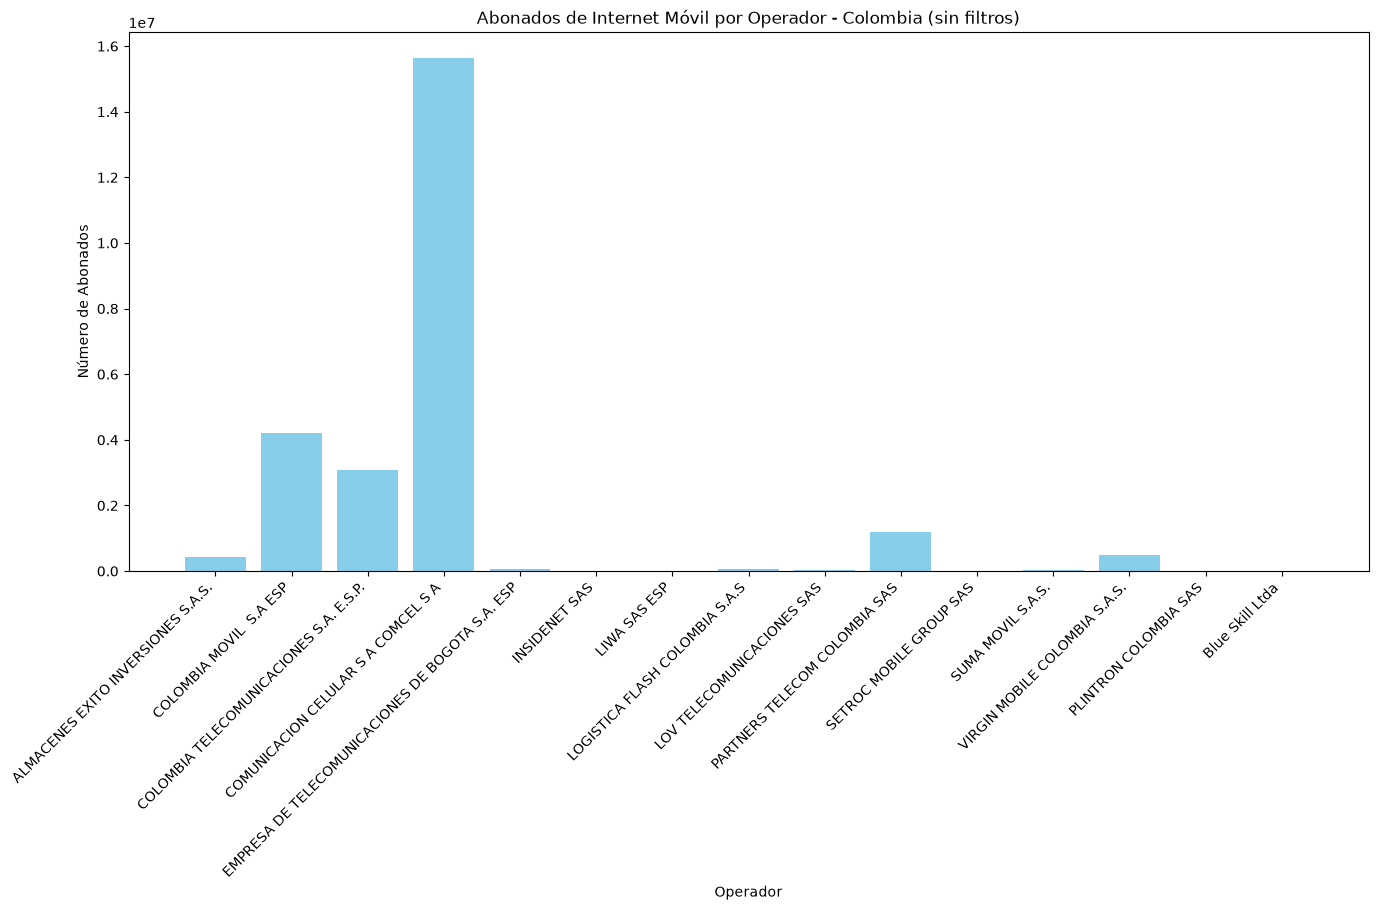

In [6]:
plt.figure(figsize=(16, 7))
plt.bar(df_abonados_moviles["PROVEEDOR"], 
        df_abonados_moviles["No. ABONADOS"],
        color="skyblue", label="Número de abonados")
plt.title("Abonados de Internet Móvil por Operador - Colombia (sin filtros)")
plt.xlabel("Operador")
plt.ylabel("Número de Abonados")
plt.xticks(rotation=45, ha="right")

plt.show()

In [7]:
#Filtro para el año 2025 trimestre 4 (Registros más recientes)
df_abonados_moviles_filtro = df_abonados_moviles[
    (df_abonados_moviles["AÑO"] == 2025) & 
    (df_abonados_moviles["TRIMESTRE"] == 4) &
    (df_abonados_moviles["TERMINAL"]== "TELÉFONO MÓVIL")
]

#DataFrame para Abonados tipo PREPAGO
df_abonados_prep = df_abonados_moviles_filtro[
    df_abonados_moviles_filtro["SEGMENTO"] == "PREPAGO"
]

#DataFrame para Abonados tipo POSPAGO
df_abonados_pos = df_abonados_moviles_filtro[
    df_abonados_moviles_filtro["SEGMENTO"] == "POSPAGO"
]

In [8]:
#Pivot para organizar por PROVEEDOR y por tecnología
pivot_pre = df_abonados_prep.pivot_table(
    index="PROVEEDOR",
    columns="TECNOLOGÍA",
    values="No. ABONADOS",
    aggfunc="sum",
    fill_value=0
)

pivot_pos = df_abonados_pos.pivot_table(
    index="PROVEEDOR",
    columns="TECNOLOGÍA",
    values="No. ABONADOS",
    aggfunc="sum",
    fill_value=0
)

In [9]:
#Organizando de mayor a menor

pivot_pre['TOTAL'] = pivot_pre.sum(axis=1)
pivot_pre = pivot_pre.sort_values('TOTAL', ascending = False)
pivot_pre = pivot_pre.drop(columns = 'TOTAL')

pivot_pos['TOTAL'] = pivot_pre.sum(axis=1)
pivot_pos = pivot_pos.sort_values('TOTAL', ascending = False)
pivot_pos = pivot_pos.drop(columns = 'TOTAL')

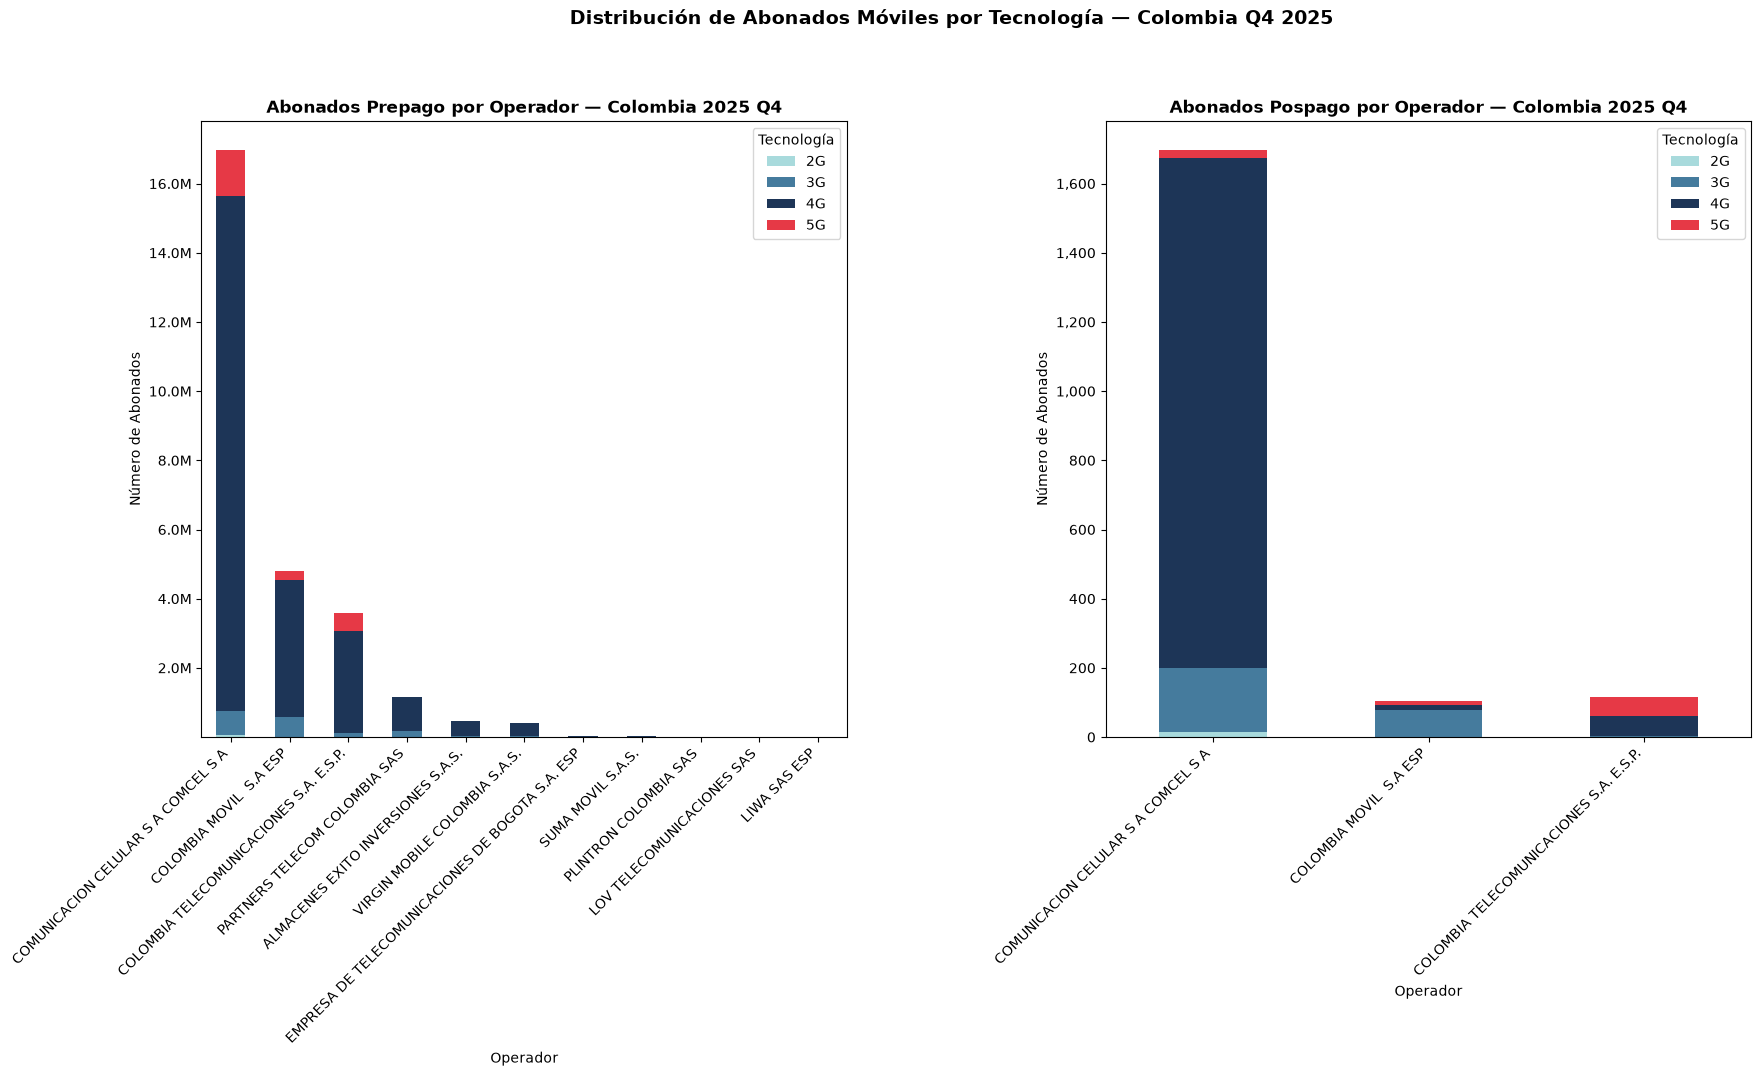

In [10]:
# Paleta de colores por tecnología
colores = {
    "2G": "#A8DADC",
    "3G": "#457B9D", 
    "4G": "#1D3557",
    "5G": "#E63946"
}

# Formatter para eje Y
formatter = mticker.FuncFormatter(
    lambda x, _: f"{x/1_000_000:.1f}M" if x >= 1_000_000 else f"{x:,.0f}"
)

# Crear subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Prepago
pivot_pre.plot(kind="bar", stacked=True, ax=ax1, 
               color=[colores.get(col, "gray") for col in pivot_pre.columns])
ax1.set_title("Abonados Prepago por Operador — Colombia 2025 Q4", fontsize=12, fontweight="bold")
ax1.legend(title="Tecnología")
ax1.set_xlabel("Operador", fontsize=10)
ax1.set_ylabel("Número de Abonados", fontsize=10)
ax1.yaxis.set_major_formatter(formatter)
ax1.tick_params(axis="x", rotation=45)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")


# Pospago
pivot_pos.plot(kind="bar", stacked=True, ax=ax2,
               color=[colores.get(col, "gray") for col in pivot_pos.columns])
ax2.set_title("Abonados Pospago por Operador — Colombia 2025 Q4", fontsize=12, fontweight="bold")
ax2.legend(title="Tecnología")
ax2.set_xlabel("Operador", fontsize=10)
ax2.set_ylabel("Número de Abonados", fontsize=10)
ax2.yaxis.set_major_formatter(formatter)
ax2.tick_params(axis="x", rotation=45)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")


fig.suptitle("Distribución de Abonados Móviles por Tecnología — Colombia Q4 2025", 
             fontsize=14, fontweight="bold", y=1.02)

plt.subplots_adjust(wspace=0.4)
plt.savefig("../dashboard/capturas/abonados_por_tecnologia_2025_Q4.png", 
            dpi=150, 
            bbox_inches="tight")
plt.show()

#### Hallazgos #1

El mercado móvil colombiano es dominado ampliamente por el segmento 
prepago, con más de 25 millones de abonados frente a aproximadamente 
1.900 en pospago. Claro lidera en ambos segmentos, concentrando más 
del 60% del mercado prepago. Esta distribución refleja las condiciones 
socioeconómicas del país, donde los planes de contrato mensual tienen 
menor penetración que el acceso por recarga.

### 2. ¿Cómo evolucionó el tráfico de datos móviles por proveedor 2023-2025?
##### Para esta pregunta, tabajaremos con trafico_movil.csv

In [11]:
#Validaciones generales
print(df_trafico_movil.columns.tolist())
print(df_trafico_movil["PROVEEDOR"].unique())
print(df_trafico_movil.head(3))

['AÑO', 'TRIMESTRE', 'PROVEEDOR', 'SEGMENTO', 'TRÁFICO (MB)']
<StringArray>
[              'ALMACENES EXITO INVERSIONES S.A.S.',
                          'COLOMBIA MOVIL  S.A ESP',
          'COLOMBIA TELECOMUNICACIONES S.A. E.S.P.',
              'COMUNICACION CELULAR S A COMCEL S A',
 'EMPRESA DE TELECOMUNICACIONES DE BOGOTA S.A. ESP',
                                    'INSIDENET SAS',
                                     'LIWA SAS ESP',
                   'LOGISTICA FLASH COLOMBIA S.A.S',
                       'LOV TELECOMUNICACIONES SAS',
                    'PARTNERS TELECOM COLOMBIA SAS',
                          'SETROC MOBILE GROUP SAS',
                                'SUMA MOVIL S.A.S.',
                    'VIRGIN MOBILE COLOMBIA S.A.S.',
                            'PLINTRON COLOMBIA SAS',
                                  'Blue Skill Ltda']
Length: 15, dtype: str
    AÑO  TRIMESTRE                           PROVEEDOR SEGMENTO  TRÁFICO (MB)
0  2023          2  ALMACENE

In [12]:
#Creación de nueva columna que suma Año y trimestre
df_trafico_movil['PERIODO'] = df_trafico_movil['AÑO'].astype(str) + '-Q' + df_trafico_movil['TRIMESTRE'].astype(str)

In [13]:
operadores = [
    "COMUNICACION CELULAR S A COMCEL S A",
    "COLOMBIA MOVIL  S.A ESP",
    "COLOMBIA TELECOMUNICACIONES S.A. E.S.P."
]

df_trafico_filtro = df_trafico_movil[df_trafico_movil["PROVEEDOR"].isin(operadores)]

In [14]:
#Agrupamos por preiodo y proveedor
df_trafico_filtro.groupby(["PERIODO", "PROVEEDOR"])["TRÁFICO (MB)"].sum().reset_index

<bound method Series.reset_index of PERIODO  PROVEEDOR                              
2023-Q2  COLOMBIA MOVIL  S.A ESP                     98496889337
         COLOMBIA TELECOMUNICACIONES S.A. E.S.P.     56263194148
         COMUNICACION CELULAR S A COMCEL S A        260632795786
2023-Q3  COLOMBIA MOVIL  S.A ESP                    113526986337
         COLOMBIA TELECOMUNICACIONES S.A. E.S.P.     64460683424
         COMUNICACION CELULAR S A COMCEL S A        265890010132
2023-Q4  COLOMBIA MOVIL  S.A ESP                    117558033634
         COLOMBIA TELECOMUNICACIONES S.A. E.S.P.     69892424326
         COMUNICACION CELULAR S A COMCEL S A        289945625346
2024-Q1  COLOMBIA MOVIL  S.A ESP                    117586395519
         COLOMBIA TELECOMUNICACIONES S.A. E.S.P.     73222416387
         COMUNICACION CELULAR S A COMCEL S A        316849977572
2024-Q2  COLOMBIA MOVIL  S.A ESP                    118717594627
         COLOMBIA TELECOMUNICACIONES S.A. E.S.P.     77265300695
     

In [15]:
#Pivot para reorganizar la tabla
pivot_trafico = df_trafico_filtro.pivot_table(
    index="PERIODO",
    columns="PROVEEDOR",
    values="TRÁFICO (MB)",
    aggfunc="sum",
    fill_value=0
)

In [16]:
pivot_trafico = pivot_trafico.sort_values('PERIODO', ascending = True)

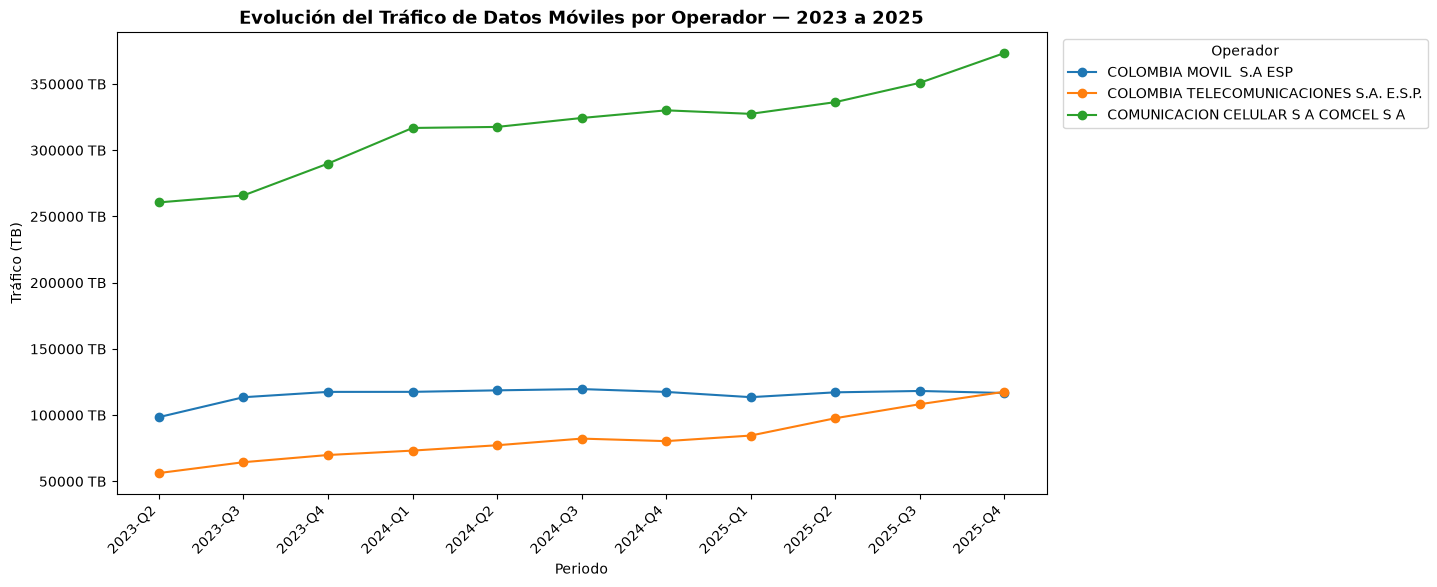

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

pivot_trafico.plot(kind="line", marker="o", ax=ax)

ax.set_title("Evolución del Tráfico de Datos Móviles por Operador — 2023 a 2025", 
             fontsize=13, fontweight="bold")
ax.set_xlabel("Periodo", fontsize=10)
ax.set_ylabel("Tráfico (TB)", fontsize=10)
ax.legend(title="Operador", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticks(range(len(pivot_trafico.index)))
ax.set_xticklabels(pivot_trafico.index, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1_000_000:.0f} TB"
))

plt.savefig("../dashboard/capturas/trafico_por_operador_2023_2025.png", 
            dpi=150, bbox_inches="tight")
plt.show()

#### Hallazgos #2

Claro (COMCEL) domina ampliamente el tráfico de datos móviles en Colombia,
manteniendo un volumen consistentemente superior a los 250.000 TB por trimestre
y con tendencia creciente, alcanzando aproximadamente 370.000 TB en Q4 2025.

Tigo (Colombia Móvil) y Movistar (Colombia Telecomunicaciones) muestran
volúmenes similares, ambos por debajo de los 120.000 TB. Notablemente,
Movistar muestra una tendencia de crecimiento más pronunciada en 2025,
acercándose a los niveles de Tigo por primera vez en el periodo analizado.

El tráfico total del sector ha crecido de forma sostenida entre 2023 y 2025,
reflejando el aumento en el consumo de datos móviles en Colombia.

### 3. ¿Cómo es la distribución del 5G en Colombia — qué departamentos lideran y cuáles se quedan atrás?
##### Para esta pregunta, tabajaremos con cobertura_movil_por_municipio.csv

In [18]:
print(df_cobertura_movil_por_municipio.columns.tolist())
print(df_cobertura_movil_por_municipio.shape)
print(df_cobertura_movil_por_municipio.head(3))

['AÑO', 'TRIMESTRE', 'PROVEEDOR', 'CÓDIGO DANE', 'DEPARTAMENTO', 'CÓDIGO DANE.1', 'MUNICIPIO', 'CABECERA MUNICIPAL ', 'CÓDIGO DANE.2', 'CENTRO POBLADO', '2G', '3G', 'HSPA+', '4G', 'LTE', '5G']
(128022, 16)
    AÑO  TRIMESTRE                PROVEEDOR  CÓDIGO DANE DEPARTAMENTO  \
0  2023          2  COLOMBIA MOVIL  S.A ESP           91     AMAZONAS   
1  2023          2  COLOMBIA MOVIL  S.A ESP           91     AMAZONAS   
2  2023          2  COLOMBIA MOVIL  S.A ESP           91     AMAZONAS   

   CÓDIGO DANE.1    MUNICIPIO CABECERA MUNICIPAL   CÓDIGO DANE.2  \
0          91263   EL ENCANTO                   N              0   
1          91430  LA VICTORIA                   N              0   
2          91001      LETICIA                   N       91001025   

       CENTRO POBLADO     2G     3G  HSPA+    4G    LTE     5G  
0  SIN CENTRO POBLADO  False  False  False  True  False  False  
1  SIN CENTRO POBLADO  False  False  False  True  False  False  
2            PALMERAS  False  Fal

In [19]:
print(df_cobertura_movil_por_municipio["AÑO"].unique())
print(df_cobertura_movil_por_municipio["TRIMESTRE"].unique())

[2023 2024 2025]
[2 3 4 1]


In [20]:
# Filtrado para el periodo de nuestro interés, en este caso, el último periodo
df_cobertura_filtro = df_cobertura_movil_por_municipio[(df_cobertura_movil_por_municipio["AÑO"] == 2025)
                                                    & (df_cobertura_movil_por_municipio["TRIMESTRE"] == 4)
]

In [21]:
#Nos interesa saber, si al menos un operador cubre ese municipio
df_cobertura_filtro.groupby(["DEPARTAMENTO", "MUNICIPIO"])[["2G","3G","HSPA+","4G","LTE","5G"]].any()

2G     3G  HSPA+    4G    LTE     5G
DEPARTAMENTO MUNICIPIO                                              
AMAZONAS     EL ENCANTO       True   True   True  True  False  False
             LA CHORRERA      True  False  False  True  False  False
             LA PEDRERA       True  False  False  True  False  False
             LA VICTORIA     False   True   True  True  False  False
             LETICIA          True   True   True  True  False  False
...                            ...    ...    ...   ...    ...    ...
VAUPÉS       YAVARATÉ         True  False  False  True  False  False
VICHADA      CUMARIBO         True   True   True  True  False  False
             LA PRIMAVERA     True   True   True  True  False  False
             PUERTO CARREÑO   True   True   True  True  False  False
             SANTA ROSALÍA    True   True   True  True  False  False

[1122 rows x 6 columns]

In [22]:
if "TIENE_COBERTURA" in df_cobertura_filtro.columns:
    df_cobertura_filtro = df_cobertura_filtro.drop(columns="TIENE_COBERTURA")
df_cobertura_filtro["TIENE_COBERTURA"] = df_cobertura_filtro[["2G","3G","HSPA+","4G","LTE","5G"]].any(axis=1)

##### ¿Existe algún municipio sin ningún tipo de cobertura en Colombia?

In [23]:
# Resultado del groupby guardado en variable
df_municipios = df_cobertura_filtro.groupby(
    ["DEPARTAMENTO", "MUNICIPIO"])[["2G","3G","HSPA+","4G","LTE","5G"]].any().reset_index()

# Columna de cobertura total
df_municipios["TIENE_COBERTURA"] = df_municipios[["2G","3G","HSPA+","4G","LTE","5G"]].any(axis=1)

# Contar por departamento
df_depto = df_municipios.groupby("DEPARTAMENTO")["TIENE_COBERTURA"].agg(
    CON_COBERTURA="sum",
    SIN_COBERTURA=lambda x: (~x).sum()
).reset_index()

print("Municipios sin cobertura de comunicaciones móviles:  ")
print(df_depto["SIN_COBERTURA"].unique().sum())

Municipios sin cobertura de comunicaciones móviles:  
0


##### ¿Existe algún municipio sin 4G?

In [24]:
# Municipios con y sin cobertura 4G
df_municipios["TIENE_4G_O_5G"] = df_municipios["4G"] | df_municipios["5G"]
df_municipios["SOLO_2G_3G"] = (
    (df_municipios["2G"] | df_municipios["3G"] | df_municipios["HSPA+"]) & 
    ~df_municipios["4G"] & 
    ~df_municipios["5G"]
)

# Contar por departamento
df_depto = df_municipios.groupby("DEPARTAMENTO").agg(
    CON_4G_O_5G = ("TIENE_4G_O_5G", "sum"),
    SOLO_2G_3G  = ("SOLO_2G_3G", "sum")
).reset_index()

print(df_depto.sort_values("SOLO_2G_3G", ascending=False).head(33))

                                         DEPARTAMENTO  CON_4G_O_5G  SOLO_2G_3G
0                                            AMAZONAS           11           0
1                                           ANTIOQUIA          125           0
2                                              ARAUCA            7           0
3   ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANT...            2           0
4                                           ATLÁNTICO           23           0
5                                         BOGOTÁ D.C.            1           0
6                                             BOLÍVAR           46           0
7                                              BOYACÁ          123           0
8                                              CALDAS           27           0
9                                             CAQUETA           16           0
10                                           CASANARE           19           0
11                                              CAUC

###### Todos los municipios de Colombia cuentan con cobertura de la tecnología 4G de por lo menos un operador. 

#### Municipios con 5G en Colombia

In [25]:
df_municipios["TIENE_5G"] = df_municipios["5G"]

df_depto = df_municipios.groupby("DEPARTAMENTO").agg(
    TOTAL_MUNICIPIOS = ("MUNICIPIO", "count"),
    CON_4G = ("4G", "sum"),
    CON_5G = ("5G", "sum")
).reset_index()

# Porcentaje de municipios con 5G por departamento
df_depto["PCT_5G"] = (df_depto["CON_5G"] / df_depto["TOTAL_MUNICIPIOS"] * 100).round(1)

print(df_depto.sort_values("PCT_5G", ascending=False))

                                         DEPARTAMENTO  TOTAL_MUNICIPIOS  \
5                                         BOGOTÁ D.C.                 1   
3   ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANT...                 2   
26                                          RISARALDA                14   
25                                            QUINDÍO                12   
30                                    VALLE DEL CAUCA                42   
9                                             CAQUETA                16   
17                                           GUAVIARE                 4   
21                                               META                29   
24                                           PUTUMAYO                13   
1                                           ANTIOQUIA               125   
4                                           ATLÁNTICO                23   
10                                           CASANARE                19   
23                       

C:\Users\perez\AppData\Local\Temp\ipykernel_16580\3666769640.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(df_depto["DEPARTAMENTO"], rotation=45, ha="right")


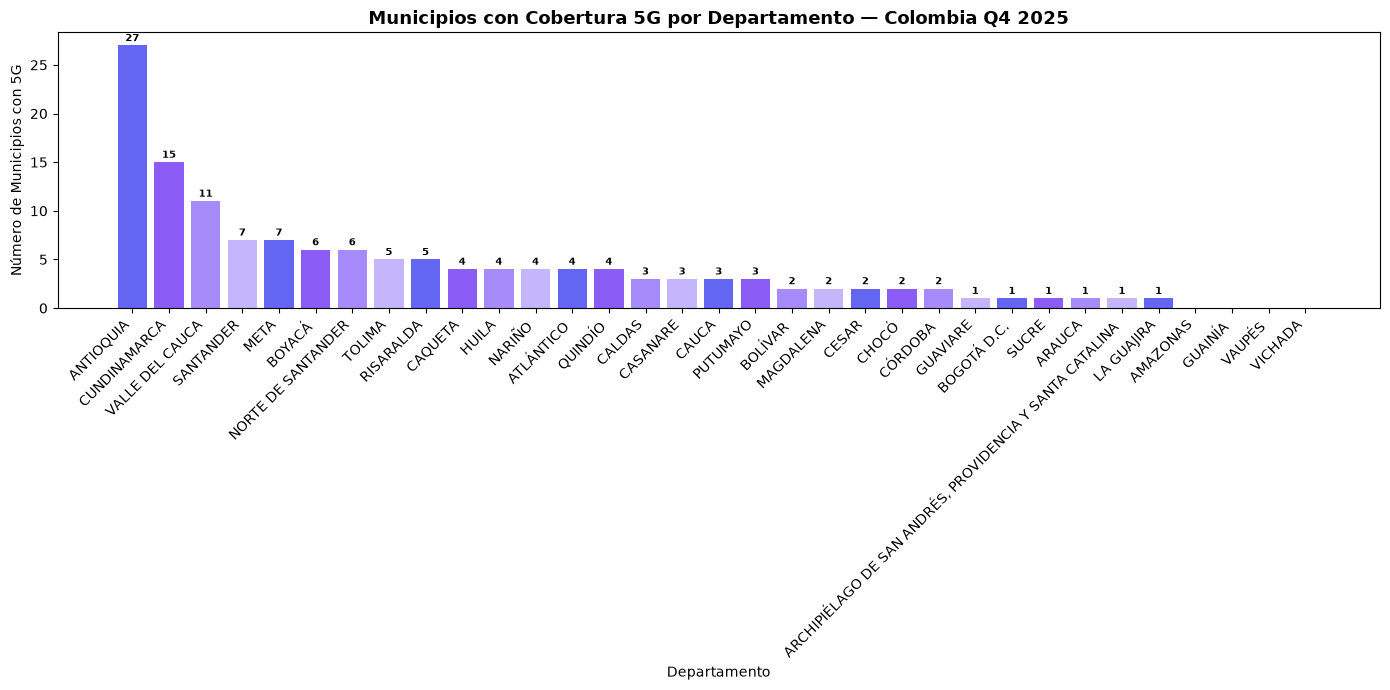

In [37]:
df_depto = df_depto.sort_values(["CON_5G"], ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))

colores_modernos = ["#6366F1", "#8B5CF6", "#A78BFA", "#C4B5FD"]
colores_barras = [colores_modernos[i % len(colores_modernos)] 
                  for i in range(len(df_depto))]

bars = ax.bar(df_depto["DEPARTAMENTO"], 
              df_depto["CON_5G"],
              color=colores_barras)

# Valor encima de cada barra
for bar in bars:
    valor = bar.get_height()
    if valor > 0:
        ax.text(bar.get_x() + bar.get_width() / 2,
                valor + 0.2,
                str(int(valor)),
                ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_title("Municipios con Cobertura 5G por Departamento — Colombia Q4 2025",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Departamento", fontsize=10)
ax.set_ylabel("Número de Municipios con 5G", fontsize=10)
ax.set_xticklabels(df_depto["DEPARTAMENTO"], rotation=45, ha="right")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../dashboard/capturas/cobertura_5G_por_departamento.png",
            dpi=150, bbox_inches="tight")
plt.show() 

#### Hallasgo #3
##### Pregunta 3 — ¿Qué departamentos lideran la adopción del 5G en Colombia?

*Nota metodológica: Al analizar los datos de cobertura municipal 
se encontró que el 100% de los municipios reportados por el MinTIC 
tienen cobertura 4G de al menos un operador, y ningún municipio 
registra cobertura exclusiva de 2G o 3G. Esto indica que la brecha 
digital en Colombia ya no es de 4G vs tecnologías anteriores, 
sino de 5G vs sin 5G. La pregunta fue ajustada para reflejar 
este hallazgo.*

*Es importante reconocer que departamentos como Vichada cuentan con pocos municipios (4) por lo que será de los últimos en lista, sin embargo, ninguno de sus municipios cuenta con 5G*

### 4. ¿Relación entre líneas móviles e ingresos por proveedor?

In [27]:
print(df_lineas_moviles.head(10))


    AÑO  TRIMESTRE                                         PROVEEDOR  \
0  2023          2                ALMACENES EXITO INVERSIONES S.A.S.   
1  2023          2                           COLOMBIA MOVIL  S.A ESP   
2  2023          2           COLOMBIA TELECOMUNICACIONES S.A. E.S.P.   
3  2023          2               COMUNICACION CELULAR S A COMCEL S A   
4  2023          2  EMPRESA DE TELECOMUNICACIONES DE BOGOTA S.A. ESP   
5  2023          2                                      LIWA SAS ESP   
6  2023          2                    LOGISTICA FLASH COLOMBIA S.A.S   
7  2023          2                        LOV TELECOMUNICACIONES SAS   
8  2023          2                     PARTNERS TELECOM COLOMBIA SAS   
9  2023          2                           SETROC MOBILE GROUP SAS   

   LÍNEAS EN SERVICIO  LÍNEAS PREPAGO  LÍNEAS POSPAGO  LÍNEAS ACTIVADAS  \
0             1717073         1717073               0            219688   
1            15167954        11578344         3589610    

In [28]:
print(df_ingresos_por_voz.head(10))

    AÑO  TRIMESTRE                                         PROVEEDOR  \
0  2023          2                ALMACENES EXITO INVERSIONES S.A.S.   
1  2023          2                           COLOMBIA MOVIL  S.A ESP   
2  2023          2           COLOMBIA TELECOMUNICACIONES S.A. E.S.P.   
3  2023          2               COMUNICACION CELULAR S A COMCEL S A   
4  2023          2  EMPRESA DE TELECOMUNICACIONES DE BOGOTA S.A. ESP   
5  2023          2                                      LIWA SAS ESP   
6  2023          2                    LOGISTICA FLASH COLOMBIA S.A.S   
7  2023          2                        LOV TELECOMUNICACIONES SAS   
8  2023          2                     PARTNERS TELECOM COLOMBIA SAS   
9  2023          2                                 SUMA MOVIL S.A.S.   

   CONSUMO PREPAGO  CONSUMO POSPAGO  INGRESOS OPERACIONALES  
0       2240155618                0              2240155618  
1      28751744453      53044517609             81796262062  
2      10945370854   

In [29]:
#Filtramos para tener los datos del último periodo registrado: 2025 Q4

df_lineas_moviles_filtro = df_lineas_moviles[(df_lineas_moviles["AÑO"] == 2025) &
                                            (df_lineas_moviles["TRIMESTRE"] == 4)
]

df_ingresos_por_voz_filtro = df_ingresos_por_voz[(df_ingresos_por_voz["AÑO"] == 2025) &
                                            (df_ingresos_por_voz["TRIMESTRE"] == 4)
]

In [30]:
#Agrupamos por proveedor en líneas móviles
df_lineas_agrup = df_lineas_moviles_filtro.groupby("PROVEEDOR")["LÍNEAS EN SERVICIO"].sum().reset_index()

In [31]:
#Agrupamos por proveedor en ingresos
df_ingresos_agrup = df_ingresos_por_voz_filtro.groupby("PROVEEDOR")["INGRESOS OPERACIONALES"].sum().reset_index()

In [32]:
#Unimos ambas tablas
df_ingresos_vs_lineas = pd.merge(df_lineas_agrup, df_ingresos_agrup, on="PROVEEDOR")
print(df_ingresos_vs_lineas.sort_values("INGRESOS OPERACIONALES", ascending = False))


                                           PROVEEDOR  LÍNEAS EN SERVICIO  \
3                COMUNICACION CELULAR S A COMCEL S A            42665092   
2            COLOMBIA TELECOMUNICACIONES S.A. E.S.P.            23068639   
1                            COLOMBIA MOVIL  S.A ESP            17512467   
7                      PARTNERS TELECOM COLOMBIA SAS             6156330   
0                 ALMACENES EXITO INVERSIONES S.A.S.             2431134   
10                     VIRGIN MOBILE COLOMBIA S.A.S.             3323908   
4   EMPRESA DE TELECOMUNICACIONES DE BOGOTA S.A. ESP              168077   
9                                  SUMA MOVIL S.A.S.               52355   
5                                       LIWA SAS ESP               12413   
6                         LOV TELECOMUNICACIONES SAS              200738   
8                              PLINTRON COLOMBIA SAS                7175   

    INGRESOS OPERACIONALES  
3             161690113479  
2             145877744662  


In [33]:
print(df_ingresos_vs_lineas.shape[0])
print(df_ingresos_vs_lineas["PROVEEDOR"])

11
0                   ALMACENES EXITO INVERSIONES S.A.S.
1                              COLOMBIA MOVIL  S.A ESP
2              COLOMBIA TELECOMUNICACIONES S.A. E.S.P.
3                  COMUNICACION CELULAR S A COMCEL S A
4     EMPRESA DE TELECOMUNICACIONES DE BOGOTA S.A. ESP
5                                         LIWA SAS ESP
6                           LOV TELECOMUNICACIONES SAS
7                        PARTNERS TELECOM COLOMBIA SAS
8                                PLINTRON COLOMBIA SAS
9                                    SUMA MOVIL S.A.S.
10                       VIRGIN MOBILE COLOMBIA S.A.S.
Name: PROVEEDOR, dtype: str


In [34]:
operadores = [
    "COMUNICACION CELULAR S A COMCEL S A",
    "COLOMBIA MOVIL  S.A ESP",
    "COLOMBIA TELECOMUNICACIONES S.A. E.S.P.", 
    "PARTNERS TELECOM COLOMBIA SAS", 
    "ALMACENES EXITO INVERSIONES S.A.S.",
    "VIRGIN MOBILE COLOMBIA S.A.S."
]
df_ingresos_vs_lineas_5 = df_ingresos_vs_lineas[df_ingresos_vs_lineas["PROVEEDOR"].isin(operadores)]

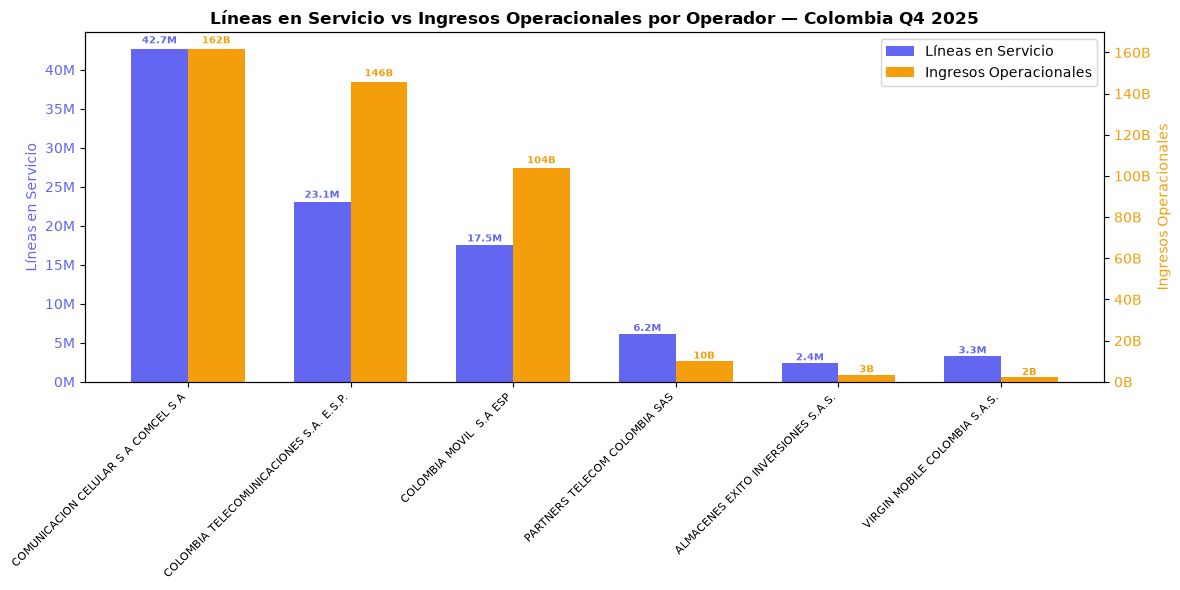

In [39]:
df_ingresos_vs_lineas_5 = df_ingresos_vs_lineas_5.sort_values(["INGRESOS OPERACIONALES"], ascending= False)

fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(df_ingresos_vs_lineas_5))
ancho = 0.35

# Barras de líneas en servicio — eje izquierdo
bars1 = ax1.bar([i - ancho/2 for i in x],
                df_ingresos_vs_lineas_5["LÍNEAS EN SERVICIO"],
                width=ancho, color="#6366F1", label="Líneas en Servicio")

ax1.set_ylabel("Líneas en Servicio", fontsize=10, color="#6366F1")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1_000_000:.0f}M"))
ax1.tick_params(axis="y", labelcolor="#6366F1")

for bar in bars1:
    valor = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2,
             valor + valor * 0.01,
             f"{valor/1_000_000:.1f}M",
             ha="center", va="bottom", fontsize=7, 
             color="#6366F1", fontweight="bold")

# Barras de ingresos — eje derecho


ax2 = ax1.twinx()
bars2 = ax2.bar([i + ancho/2 for i in x],
                df_ingresos_vs_lineas_5["INGRESOS OPERACIONALES"],
                width=ancho, color="#F59E0B", label="Ingresos Operacionales")

ax2.set_ylabel("Ingresos Operacionales", fontsize=10, color="#F59E0B")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1_000_000_000:.0f}B"))
ax2.tick_params(axis="y", labelcolor="#F59E0B")

for bar in bars2:
    valor = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2,
             valor + valor * 0.01,
             f"{valor/1_000_000_000:.0f}B",
             ha="center", va="bottom", fontsize=7,
             color="#F59E0B", fontweight="bold")

# Eje X con nombres de operadores
ax1.set_xticks(list(x))
ax1.set_xticklabels(df_ingresos_vs_lineas_5["PROVEEDOR"], 
                     rotation=45, ha="right", fontsize=8)

# Leyenda combinada
lines = [bars1, bars2]
labels = ["Líneas en Servicio", "Ingresos Operacionales"]
ax1.legend(lines, labels, loc="upper right")

ax1.set_title("Líneas en Servicio vs Ingresos Operacionales por Operador — Colombia Q4 2025",
              fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../dashboard/capturas/lineas_vs_ingresos.png", 
            dpi=150, bbox_inches="tight")

plt.savefig("../dashboard/capturas/lineas_vs_ingresos.png", 
            dpi=150, bbox_inches="tight")
plt.show()

#### Hallazgo #4

Existe una correlación positiva entre líneas en servicio e ingresos 
operacionales. Claro lidera ampliamente con 42.7M de líneas y 162B 
en ingresos operacionales.

El caso más interesante es Movistar (Colombia Telecomunicaciones) 
que con 23.1M de líneas genera 146B en ingresos, superando 
proporcionalmente a Tigo que con 17.5M de líneas genera 104B. 
Esto sugiere que Movistar tiene un ingreso promedio por usuario 
más alto, posiblemente por mayor proporción de clientes pospago 
o planes de mayor valor.

Almacenes Éxito y Virgin Mobile con 2.4M y 3.3M de líneas 
respectivamente generan ingresos mínimos — operan como OMVs 
(Operadores Móviles Virtuales) que revenden la red de los 
operadores grandes sin infraestructura propia.